In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from scipy.stats import levy_stable
from src.simulators import *
from src.estimators import *

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

# Comparative Levy Flight Analysis: Albatrosses and White Storks

This notebook applies the statistical methods validated in the previous simulation to real-world movement data from two species: the Galapagos Albatross (Phoebastria irrorata) and the White Stork (Ciconia ciconia). We test the hypothesis that foraging and migratory patterns follow a Levy Flight distribution—characterized by a power-law tail—rather than standard Brownian Motion.

## Estimation of parametres for Albatrosses 

In [2]:

df_albatross = pd.read_csv("data/clean_df_albatrosses_steps.csv")
valid_data = df_albatross.copy()

birds = valid_data.groupby('individual_id').filter(lambda x: len(x) > 50)['individual_id'].unique()

In [ ]:


results = []

for bird_id in birds:
    print(f"Bird_id: {bird_id}")
    
    data = valid_data[valid_data['individual_id'] == bird_id]['step_m'].values
    mcc = mcculloch_estimator(data)
    kou = koutrouvelis_estimator(data)

    try:
        mle_raw = levy_stable.fit(data[:1000], method='mle')
        mle = (mle_raw[0], mle_raw[1], mle_raw[3], mle_raw[2])
    except:
        mle = (np.nan,)*4

    methods = {"McCulloch": mcc, "Koutrouvelis": kou, "SciPy_MLE": mle}
    
    for m_name, p in methods.items():
        results.append({
            "Individual_ID": bird_id,
            "Method": m_name,
            "N_Samples": len(data),
            "Est_Alpha": p[0], 
            "Est_Beta": p[1], 
            "Est_Scale": p[2], 
            "Est_Mu": p[3]
        })
    print(results)
    
results_df = pd.DataFrame(results)

display(results_df.round(3))


Bird_id: 1103-1103
[{'Individual_ID': '1103-1103', 'Method': 'McCulloch', 'N_Samples': 103, 'Est_Alpha': np.float64(0.7395346041971049), 'Est_Beta': np.float64(1.0), 'Est_Scale': np.float64(757.1292770982984), 'Est_Mu': np.float64(4.424959012028741)}, {'Individual_ID': '1103-1103', 'Method': 'Koutrouvelis', 'N_Samples': 103, 'Est_Alpha': np.float64(0.6939171577717158), 'Est_Beta': np.float64(-0.5801484554368406), 'Est_Scale': np.float64(1.963094406673927), 'Est_Mu': np.float64(2.1425901548044943)}, {'Individual_ID': '1103-1103', 'Method': 'SciPy_MLE', 'N_Samples': 103, 'Est_Alpha': nan, 'Est_Beta': nan, 'Est_Scale': nan, 'Est_Mu': nan}]
Bird_id: 1163-1163
[{'Individual_ID': '1103-1103', 'Method': 'McCulloch', 'N_Samples': 103, 'Est_Alpha': np.float64(0.7395346041971049), 'Est_Beta': np.float64(1.0), 'Est_Scale': np.float64(757.1292770982984), 'Est_Mu': np.float64(4.424959012028741)}, {'Individual_ID': '1103-1103', 'Method': 'Koutrouvelis', 'N_Samples': 103, 'Est_Alpha': np.float64(0.69

,Individual_ID,Method,N_Samples,Est_Alpha,Est_Beta,Est_Scale,Est_Mu
0,1103-1103,McCulloch,103,0.740,1.000,757.129,4.425
1,1103-1103,Koutrouvelis,103,0.694,-0.580,1.963,2.143
2,1103-1103,SciPy_MLE,103,NaN,NaN,NaN,NaN
3,1163-1163,McCulloch,1470,0.963,1.000,4412.642,2352.567
4,1163-1163,Koutrouvelis,1470,0.346,-0.566,22.897,1.978
...,...,...,...,...,...,...,...
61,unbanded-159,Koutrouvelis,2304,0.523,-0.635,5.709,2.135
62,unbanded-159,SciPy_MLE,2304,0.975,0.940,12.659,-292.060
63,unbanded-160,McCulloch,200,0.525,1.000,363.184,10.688
64,unbanded-160,Koutrouvelis,200,0.564,-0.313,4.000,3.430


Est_Alpha         Est_Beta        
                  mean     std     mean     std
Method                                         
Koutrouvelis    0.6365  0.3429  -0.5391  0.1852
McCulloch       0.9517  0.3726   1.0000  0.0000
SciPy_MLE       0.8712  0.4118   0.9787  0.0425

In [ ]:
results_df.to_csv("data/albatroses_parameters.csv", index=False)

[{'Individual_ID': '1103-1103',
  'Method': 'McCulloch',
  'N_Samples': 103,
  'Est_Alpha': nan,
  'Est_Beta': nan,
  'Est_Scale': nan,
  'Est_Mu': nan},
 {'Individual_ID': '1103-1103',
  'Method': 'Koutrouvelis',
  'N_Samples': 103,
  'Est_Alpha': nan,
  'Est_Beta': nan,
  'Est_Scale': nan,
  'Est_Mu': nan},
 {'Individual_ID': '1103-1103',
  'Method': 'SciPy_MLE',
  'N_Samples': 103,
  'Est_Alpha': nan,
  'Est_Beta': nan,
  'Est_Scale': nan,
  'Est_Mu': nan},
 {'Individual_ID': '1163-1163',
  'Method': 'McCulloch',
  'N_Samples': 1470,
  'Est_Alpha': nan,
  'Est_Beta': nan,
  'Est_Scale': nan,
  'Est_Mu': nan},
 {'Individual_ID': '1163-1163',
  'Method': 'Koutrouvelis',
  'N_Samples': 1470,
  'Est_Alpha': nan,
  'Est_Beta': nan,
  'Est_Scale': nan,
  'Est_Mu': nan},
 {'Individual_ID': '1163-1163',
  'Method': 'SciPy_MLE',
  'N_Samples': 1470,
  'Est_Alpha': np.float64(0.8144783219054456),
  'Est_Beta': np.float64(0.9999999999991226),
  'Est_Scale': np.float64(3.7732071501091986),
  'E

## For further analysis we're choosing two albatrosses with longest data

In [3]:
df_results = pd.read_csv("data/albatroses_parameters.csv")
bird1, bird2 = valid_data['individual_id'].value_counts().head(2).index

data_bird1 = valid_data[valid_data['individual_id'] == bird1]
data_bird2 = valid_data[valid_data['individual_id'] == bird2]

threshold1 = data_bird1['step_m'].quantile(0.90)
threshold2 = data_bird2['step_m'].quantile(0.90)

data_bird1_filtered = data_bird1[data_bird1['step_m'] <= threshold1]
data_bird2_filtered = data_bird2[data_bird2['step_m'] <= threshold2]

display(df_results[df_results['Individual_ID'] == bird1])
display(df_results[df_results['Individual_ID'] == bird2])
print(data_bird1_filtered['step_m'].max())

,Individual_ID,Method,N_Samples,Est_Alpha,Est_Beta,Est_Scale,Est_Mu
60,unbanded-159,McCulloch,2304,0.685924,1.000000,1213.121302,21.004007
61,unbanded-159,Koutrouvelis,2304,0.522914,-0.634524,5.708716,2.135078
62,unbanded-159,SciPy_MLE,2304,0.974957,0.940479,12.659055,-292.059969


,Individual_ID,Method,N_Samples,Est_Alpha,Est_Beta,Est_Scale,Est_Mu
57,unbanded-156,McCulloch,1472,1.089539,1.000000,1973.200104,51.613348
58,unbanded-156,Koutrouvelis,1472,0.489247,-0.410729,7.016594,3.070336
59,unbanded-156,SciPy_MLE,1472,1.019872,0.991476,214.011523,6928.800027


16212.945481480594


In [7]:
for data in [data_bird2_filtered] :
    mcc = mcculloch_estimator(data['step_m'])
    kou = koutrouvelis_estimator(data['step_m'])
    bird_id = data["individual_id"].unique()[0]

    try:
        mle_raw = levy_stable.fit(data['step_m'][:1000], method='mle')
        mle = (mle_raw[0], mle_raw[1], mle_raw[3], mle_raw[2])
    except:
        mle = (np.nan,)*4

    methods = {"McCulloch": mcc, "Koutrouvelis": kou, "SciPy_MLE": mle}
    
    for m_name, p in methods.items():
        results.append({
            "Individual_ID": bird_id,
            "Method": m_name,
            "N_Samples": len(data),
            "Est_Alpha": p[0], 
            "Est_Beta": p[1], 
            "Est_Scale": p[2], 
            "Est_Mu": p[3]
        })
    print(results)
    

[{'Individual_ID': 'unbanded-159', 'Method': 'McCulloch', 'N_Samples': 2073, 'Est_Alpha': np.float64(0.7774775262547818), 'Est_Beta': np.float64(1.0), 'Est_Scale': np.float64(665.3213489209644), 'Est_Mu': np.float64(11.76756644493858)}, {'Individual_ID': 'unbanded-159', 'Method': 'Koutrouvelis', 'N_Samples': 2073, 'Est_Alpha': np.float64(0.5598670257629157), 'Est_Beta': np.float64(-0.6367686850927174), 'Est_Scale': np.float64(4.71006825008969), 'Est_Mu': np.float64(2.181499474348577)}, {'Individual_ID': 'unbanded-159', 'Method': 'SciPy_MLE', 'N_Samples': 2073, 'Est_Alpha': np.float64(0.41157055368704576), 'Est_Beta': np.float64(0.9589688431400876), 'Est_Scale': np.float64(4.905842786348383), 'Est_Mu': np.float64(0.5868865161615963)}, {'Individual_ID': 'unbanded-156', 'Method': 'McCulloch', 'N_Samples': 1324, 'Est_Alpha': np.float64(1.2110945367354806), 'Est_Beta': np.float64(1.0), 'Est_Scale': np.float64(1066.6982429373186), 'Est_Mu': np.float64(20.577720801922172)}, {'Individual_ID': 

In [8]:
results_df = pd.DataFrame(results)

results_df.to_csv("data/albatroses_2birds_parameters.csv", index=False)

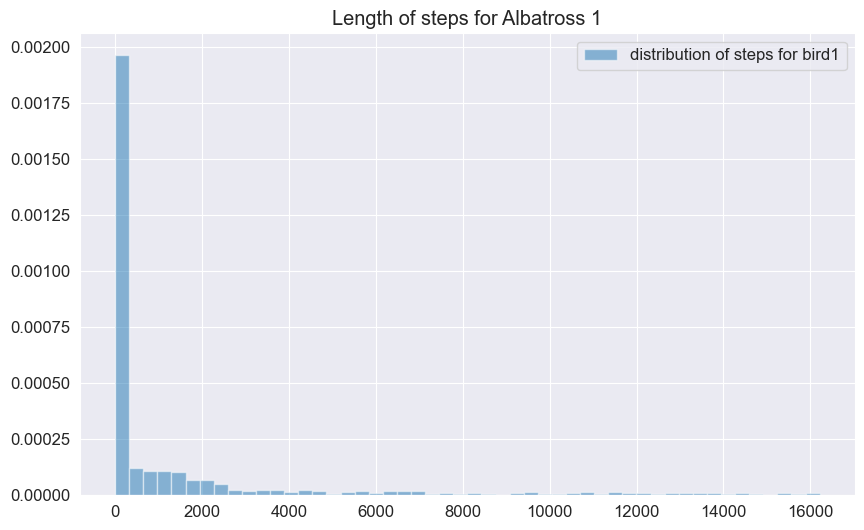

In [ ]:

plt.hist(data_bird1_filtered['step_m'], bins=50, density=True, alpha=0.5, label='distribution of steps for bird1')

plt.title("Length of steps for Albatross 1")
plt.legend()
plt.show()